<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_8_naivebayes.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Naive Bayes, Generative vs. Discriminative

In this assignment you will implement **Gaussian Naive Bayes** from scratch and compare it to a **discriminative** classifier (Logistic Regression).  
You will train both on a 2-class, 2-feature subset of the Iris dataset so decision boundaries can be plotted in 2D, then compare accuracy, training time, and qualitative differences.

---

**Learning goals**
- Implement the Naive Bayes generative model (Gaussian likelihoods, independent features).  
- Compute class priors and class-conditional parameters.  
- Visualize decision boundaries and posterior probabilities.  
- Compare to Logistic Regression (discriminative) and discuss tradeoffs.  

---

## Grading standards

| Component | Weight |
|---|---:|
| Data loading & preprocessing | 10% |
| Naive Bayes implementation (fit, predict, predict_proba) | 20% |
| Logistic Regression training & comparison | 20% |
| Decision boundary visualizations (clear & labeled) | 20% |
| Accuracy/time comparison + short writeup | 20% |
| Code tidy and notebook presentation | 10% |


---

## Description & Task Flow

You will perform the following parts.

**Part 1 — Implement Gaussian Naive Bayes (from scratch)**
- Implement a `NaiveBayes` class with these methods:
  - `fit(X, y)` — estimate class priors, per-class mean vectors, and per-class variances (use diagonal covariance because of the Naive Bayes independence assumption).
  - `predict_proba(X)` — return posterior probabilities for each class.
  - `predict(X)` — return class labels.
  - `score(X, y)` — return accuracy.
  - `generate_samples(n_samples)` — optional: sample new points from the learned generative model to demonstrate generative capability.
  - `visualize_decision_boundary(X, y)` — plot a 2D decision boundary and overlay data points and class means.

**Part 2 — Compare to Logistic Regression**
- Train `sklearn.linear_model.LogisticRegression` on the same data and compare:
  - Training time (use `time.time()` or `time.perf_counter()`).
  - Accuracy on the same train/test split.
  - Decision boundary side-by-side with Naive Bayes.
- Write a short reflection (3–5 sentences) that discusses when a generative model might be preferred over a discriminative model and vice versa.

**Data**
- Use `sklearn.datasets.load_iris()` and select two classes (for example, versicolor and virginica) and two features (e.g., petal length and petal width) to allow 2D plotting.

**Visualization requirements**
- Produce at least two labeled plots:
  1. Naive Bayes decision boundary with posterior coloring and class means.
  2. Logistic Regression decision boundary (same axes limits) for direct visual comparison.
- Optionally produce a third figure that overlays both decision boundaries.

---

## Deliverables (what to submit)
- A Colab notebook (or Jupyter) that contains:
  - Data loading and preprocessing code.
  - A `NaiveBayes` class with required methods (Part 1).
  - Training & evaluation code for Logistic Regression (Part 2).
  - Plots comparing the classifiers.
  - Short reflection paragraphs.

---

## Hints & Useful references
- Use `scipy.stats.norm.pdf` to compute 1D Gaussian likelihoods (or implement the Gaussian PDF directly).
- Use `sklearn.preprocessing.StandardScaler` to standardize features before training (optional but recommended).
- Use `np.log` versions (log-likelihood) to avoid numerical underflow when multiplying many likelihoods.
- For plotting decision boundaries create a meshgrid with `np.meshgrid` and evaluate `predict` (or `predict_proba`) on the grid.
- To sample from learned Gaussians, use `np.random.multivariate_normal` with diagonal covariances (i.e., variances on the diagonal).

---

</details>


In [58]:
# ===== Data loading and preprocessing =====
import numpy as np
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris and pick two classes + two features for 2D visualization
iris = load_iris()
X_all = iris['data']
y_all = iris['target']

# Choose classes 1 and 2 (versicolor, virginica) and features 2 and 3 (petal length, petal width)
mask = (y_all == 1) | (y_all == 2)
X = X_all[mask][:, 2:4]   # shape (n_samples, 2)
y = y_all[mask]
# Remap labels to {0,1}
y = (y == 2).astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Optional: standardize
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("X_train:", X_train_s.shape, "y_train:", y_train.shape)



X_train: (70, 2) y_train: (70,)


In [59]:
# ===== A helper function for plotting decision boundires.
# You are expected to use it appropriately to produce at least two clear,
# well-labeled visualizations comparing Naive Bayes and Logistic Regression. =====

# You do NOT need to modify this function

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import numpy as np
import time

def plot_mesh_predict(model, X, y, scaler=None, ax=None, title=None, cmap=None):
    """
    Plot decision region for a model with a .predict(X) method.
    If scaler is provided, the grid is created in scaled space.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    # define grid in original (unscaled) coordinates if scaler is provided:
    X_use = X if scaler is None else scaler.inverse_transform(X)
    x_min, x_max = X_use[:,0].min() - 1, X_use[:,0].max() + 1
    y_min, y_max = X_use[:,1].min() - 1, X_use[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # if scaler given, transform grid to scaled space for model input
    grid_in = grid if scaler is None else scaler.transform(grid)
    Z = model.predict(grid_in).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X_use[:,0], X_use[:,1], c=y, edgecolor='k')
    if title:
        ax.set_title(title)
    return ax

Logistic Regression training time: 0.0095 seconds
Logistic Regression test accuracy: 0.9000


<Axes: title={'center': 'Logistic Regression Decision Boundary'}>

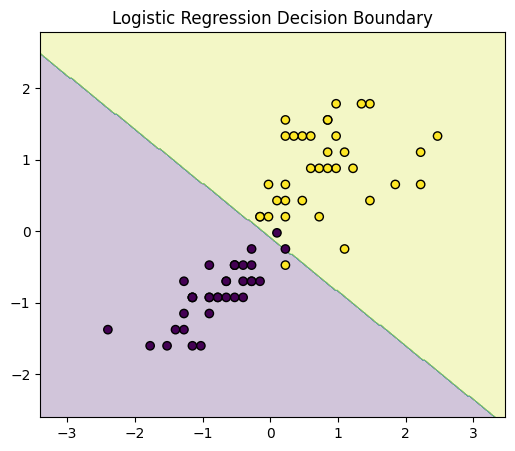

In [60]:
# ===== Implement the generative Naive Bayes =====

from sklearn.linear_model import LogisticRegression
import time

lr = LogisticRegression()

start = time.perf_counter()
lr.fit(X_train_s, y_train)
end = time.perf_counter()
lr_time = end-start

print(f"Logistic Regression training time: {end - start:.4f} seconds")
print(f"Logistic Regression test accuracy: {lr.score(X_test_s, y_test):.4f}")

plot_mesh_predict(lr, X_train_s, y_train, title="Logistic Regression Decision Boundary")

In [61]:
import scipy.stats


**Part 1 — Implement Gaussian Naive Bayes (from scratch)**
- Implement a `NaiveBayes` class with these methods:
  - `fit(X, y)` — estimate class priors, per-class mean vectors, and per-class variances (use diagonal covariance because of the Naive Bayes independence assumption).
  - `predict_proba(X)` — return posterior probabilities for each class.
  - `predict(X)` — return class labels.
  - `score(X, y)` — return accuracy.
  - `generate_samples(n_samples)` — optional: sample new points from the learned generative model to demonstrate generative capability.
  - `visualize_decision_boundary(X, y)` — plot a 2D decision boundary and overlay data points and class means.


In [88]:
# ===== Implement the generative Naive Bayes =====
class NaiveBayes:
    def __init__(self):
        self.classes = None
        self.priors = None       # shape (n_classes,)
        self.means = None        # shape (n_classes, n_features)
        self.vars = None         # shape (n_classes, n_features)  (diagonal covariance)

    def fit(self, X, y):
        """
        Estimate class priors, means, and variances per class.
        X: array-like, shape (n_samples, n_features)
        y: array-like, shape (n_samples,)
        """

        self.classes = np.unique(y)
        print(self.classes)

        n_samples, n_features = X.shape
        n_classes = len(self.classes)

        #make storage vars
        self.priors = np.zeros(n_classes)
        self.means = np.zeros((n_classes, n_features))
        self.vars = np.zeros((n_classes, n_features))


        for i,c in enumerate(self.classes):

          X_c = X[y==c] # this gives us the list of X's, shortened dimension from X, that are y==c
          # (n_class_observations, n_features)
          self.priors[i] = len(X_c)/n_samples
          self.means[i,:] = np.mean(X_c, axis=0) # gives us a row of avg features
          self.vars[i,:] = np.var(X_c, axis=0)

        return self

    def predict_proba(self, X):
        """
        Return posterior probabilities for each class.
        Output shape: (n_samples, n_classes)
        """
        #first we need to calculate gaussing pdf likelihood p(x|y=c)

        #create storage array for this
        n_samples = X.shape[0]
        n_classes = len(self.classes)

        log_posteriors = np.zeros((n_samples, n_classes))

        for i, c in enumerate(self.classes):
            # logpdf instead to get log(P(x_j | y=c))
            log_likelihoods = scipy.stats.norm.logpdf(X, loc=self.means[i], scale=np.sqrt(self.vars[i]))

            # Sum log-likelihoods across features (instead of taking the product)
            total_log_likelihood = np.sum(log_likelihoods, axis=1) # (n_samples,)

            # Add the log prior
            log_posteriors[:, i] = total_log_likelihood + np.log(self.priors[i])

        # 4. Exponentiate and normalize to get actual probabilities back
        # We use the "Log-Sum-Exp trick" here by subtracting the max value
        # before exponentiating to ensure numerical stability.
        max_log_posteriors = np.max(log_posteriors, axis=1, keepdims=True)
        exp_posteriors = np.exp(log_posteriors - max_log_posteriors)

        post_probs = exp_posteriors / np.sum(exp_posteriors, axis=1, keepdims=True)

        return post_probs

    def predict(self, X):
        """
        Return predicted class labels for each sample.
        input X: (n_samples, n_features)
        output: (n_samples,)
        """

        # p(y|x) = p(x|y)p(y)/normalize

        #but we can actually just use hard clustering on our posterior\

        posterior = self.predict_proba(X) # (n_samples, n_classes)

        # prediction = np.max(posterior, axis=1) # (n_samples,) NOPE
        prediction_indices = np.argmax(posterior, axis=1) # (n_samples,)

        #map back to labels
        prediction_labels = self.classes[prediction_indices]

        return prediction_labels

    def score(self, X, y):
        """
        Compute accuracy of predictions on (X, y).
        output: (1,)

        """
        # we want to score how many we got right.

        prediction_labels = self.predict(X) # (n_samples,)
        denominator = len(prediction_labels)

        #True/False array
        binary_correct_incorrect = prediction_labels==y # (n_samples,)
        num_correct = np.sum(binary_correct_incorrect)

        return num_correct/denominator

    def generate_samples(self, n_samples_per_class=50, random_state=None):
        """
        Optionally generate new samples from the learned generative model.
        Returns: (X_samples, y_samples)
        """
        #this is coding up the posterior predictive

        #we use the likelihood
        #p(x|y)

        # n_classes = len(self.classes)
        # n_features = self.means.shape[1]


        # # y_samples = np.array([self.classes[clss_i], ])


        # X_samples = np.random.multivariate_normal(
        #     mean=self.means,
        #     cov=self.vars,
        #     size=((n_classes*n_samples_per_class, n_features))
        #     )





        # return (X_samples, y_samples) # (X_samples, y_samples)
        pass
    def visualize_decision_boundary(self, X, y, ax=None, title=None):
        """
        Plot 2D decision boundary with training data and class means.
        Assumes 2 features.
        """
        plott = plot_mesh_predict(self, X, y, ax=ax, title=title)

        n_samples = X.shape[0]

        classes = np.unique(y, axis=0)

        for c in classes:
          #get the subset of X's for a class
          X_c = X[y==c]

          #calculate mean x for that class (axis = 0 -> for each feature)
          X_c_mean = np.mean(X_c, axis = 0)

          #put on a new point for that mean
          plott.plot(X_c_mean[0], X_c_mean[1],'ro')


        return(
          plott

        )


### Training Models:

In [89]:
testmodel1 = NaiveBayes()


In [90]:

NBA_time_start = time.perf_counter()

fit1 = testmodel1.fit(X_train_s,y_train)

NBA_time_end = time.perf_counter()

NBA_time = NBA_time_end - NBA_time_start



[0 1]


NBA Representation

Training Time = 0.0007
NBA accuracy = 0.9


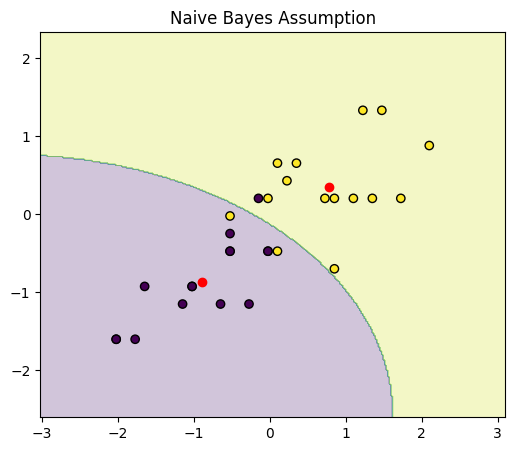

In [91]:
NBA = testmodel1.visualize_decision_boundary(X_test_s,
                                             y_test,
      title=f'Naive Bayes Assumption')


print( f"Training Time = {NBA_time:.4f}")
print(f'NBA accuracy = {testmodel1.score(X_test_s,y_test)}')

Logistic Regression:


Training time: 0.0095
LR accuracy = 0.9


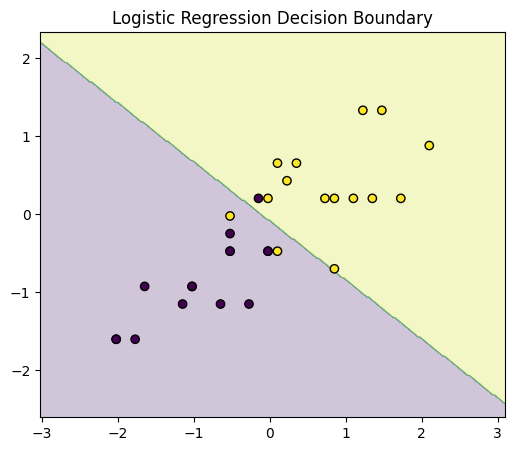

In [92]:
lr1 = plot_mesh_predict(lr, X_test_s,
                        y_test,
              title=f"Logistic Regression Decision Boundary")
print(f"Training time: {lr_time:.4f}")
print(f'LR accuracy = {lr.score(X_test_s,y_test)}')

Compare your Naive Bayes implementation to Logistic Regression in terms of:

- Accuracy: At least 2 sentences discussing which model performed better and - possible reasons why.

- Training time: At least 2 sentences comparing how fast each model trained and implications.

- Decision boundary visualization: At least 2 sentences interpreting the shapes and differences of the boundaries from your plots.



## Model Comparison ##

Interestingly enough, we have 90% accuracy on both models. Because there are only around 20 testing data points, we can't get a more accurate analysis of this, however, it makes sense that NBA did not do worse becase it is capable of doing what is not possible for a logistic regression: nonlinear boundaries. We see that the boundary created by NBA is convex, as if it has a radius with the center at the origin. This makes intuitive sense because the smallest we can have features is at zero---it would not makes sense to have a boundary that is concave instead. Something else interesting to note is that they miss the exact same points, but naive bayes is arguably "more inbetween" the classes than the log regression (i.e. more equally in the middle of the border datapoints). The training time on our Naive Bayes model is about 1/10th the training time on the Logistic Regression. It is impressive that our assumption doesn't lead to trash fitting, and because we are simplifying so much, we do actually keep O(n) speed.

###Reflection on Generative vs. Discriminative Models

I believe it's in the names---discriminative classifiers are going to be more accurate than generative classifiers. They have an easier job to learn the distribution of categories given features rather than features + categories given datapoints. Discriminative models also make fewer assumptions and therefore are a bit better calibrated.

Generative classifiers have the ability to fit very fast. They only need to count and average, while logistic regression, etc. (discriminative classifiers) need to solve least-squares and it takes longer. Another thing is that since we use bayesian modeling, the prior stops us from ruining our model via missing input features. It can also fit classes separately, do semisupervised learning, and be better deal with outliers.

**Part 2 — Compare to Logistic Regression**
- Train `sklearn.linear_model.LogisticRegression` on the same data and compare:
  - Training time (use `time.time()` or `time.perf_counter()`).
  - Accuracy on the same train/test split.
  - Decision boundary side-by-side with Naive Bayes.
- Write a short reflection (3–5 sentences) that discusses when a generative model might be preferred over a discriminative model and vice versa.

**Data**
- Use `sklearn.datasets.load_iris()` and select two classes (for example, versicolor and virginica) and two features (e.g., petal length and petal width) to allow 2D plotting.

**Visualization requirements**
- Produce at least two labeled plots:
  1. Naive Bayes decision boundary with posterior coloring and class means.
  2. Logistic Regression decision boundary (same axes limits) for direct visual comparison.
- Optionally produce a third figure that overlays both decision boundaries.

---


## Hints & Useful references
- Use `scipy.stats.norm.pdf` to compute 1D Gaussian likelihoods (or implement the Gaussian PDF directly).
- Use `sklearn.preprocessing.StandardScaler` to standardize features before training (optional but recommended).
- Use `np.log` versions (log-likelihood) to avoid numerical underflow when multiplying many likelihoods.
- For plotting decision boundaries create a meshgrid with `np.meshgrid` and evaluate `predict` (or `predict_proba`) on the grid.
- To sample from learned Gaussians, use `np.random.multivariate_normal` with diagonal covariances (i.e., variances on the diagonal).
